# 04 — Exploratory Data Analysis

**Milestone 2 · Tasks 4 & 5:** explore how goal, duration, category,
subcategory, location, updates and reward levels relate to success; create
visualisations and summary statistics; document findings that feed the
machine-learning phase.

All analysis runs on the **training split only**. Looking at test-set
relationships and then choosing features based on what you saw is leakage
by way of the analyst's memory.

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from src.features import build_model_matrix

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 50)

mpl.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})
TEAL, PLUM, CORAL, SAND = "#2E7D6F", "#7B5EA7", "#C0392B", "#D9A455"
FIG = Path("../reports/figures")

train = pd.read_parquet("../data/train_featured.parquet")
test = pd.read_parquet("../data/test_featured.parquet")
print(f"Train {train.shape[0]:,} | Test {test.shape[0]:,}")

BASE_RATE = train["success"].mean()
print(f"Overall success rate (train): {BASE_RATE:.2%}")
print(f"Majority-class accuracy baseline: {max(BASE_RATE, 1 - BASE_RATE):.2%}")

Train 30,702 | Test 7,676
Overall success rate (train): 54.74%
Majority-class accuracy baseline: 54.74%


That baseline number is the one to keep in mind throughout. Any claim that
a factor "predicts success" has to beat 54.8%, and the 80% target in the
brief represents about 25 points of real lift.

In [2]:
def success_by(frame, col, min_n=30):
    """Success rate by group, with a Wald 95% interval and group size."""
    g = frame.groupby(col, observed=True)["success"].agg(["mean", "size"])
    g = g[g["size"] >= min_n].copy()
    se = np.sqrt(g["mean"] * (1 - g["mean"]) / g["size"])
    g["ci95"] = 1.96 * se
    g["lift_vs_base"] = g["mean"] - BASE_RATE
    return g.rename(columns={"mean": "success_rate", "size": "n"})


def barh_rates(g, title, fname, color=TEAL, figsize=(8, 5)):
    g = g.sort_values("success_rate")
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(range(len(g)), g["success_rate"], xerr=g["ci95"],
            color=color, error_kw={"ecolor": "#555", "lw": 1})
    ax.axvline(BASE_RATE, color=CORAL, ls="--", lw=1.4,
               label=f"overall {BASE_RATE:.1%}")
    ax.set_yticks(range(len(g)))
    ax.set_yticklabels([f"{i}  (n={int(n):,})" for i, n in zip(g.index, g["n"])],
                       fontsize=8)
    ax.set_xlabel("Success rate")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="lower right")
    plt.tight_layout()
    plt.savefig(FIG / fname, dpi=130, bbox_inches="tight")
    plt.show()

## 4.1 Goal — the strongest launch-time signal

In [3]:
train["goal_decile"] = pd.qcut(train["goal"], 10, duplicates="drop")
goal_tbl = success_by(train, "goal_decile")
goal_tbl["median_goal"] = train.groupby("goal_decile", observed=True)["goal"].median()
goal_tbl[["median_goal", "n", "success_rate", "ci95"]].round(4)

,median_goal,n,success_rate,ci95
goal_decile,,,,
"(0.999, 750.0]",500.0,3184,0.7120,0.0157
"(750.0, 1250.0]",1000.0,3002,0.6682,0.0168
"(1250.0, 2000.0]",1800.0,3673,0.6662,0.0153
"(2000.0, 3000.0]",2700.0,3989,0.6247,0.0150
"(3000.0, 4000.0]",3600.0,2262,0.5902,0.0203
"(4000.0, 5000.0]",5000.0,3385,0.5134,0.0168
"(5000.0, 7000.0]",6000.0,2057,0.5241,0.0216
"(7000.0, 10000.0]",10000.0,3692,0.4691,0.0161
"(10000.0, 20000.0]",15000.0,3042,0.3820,0.0173


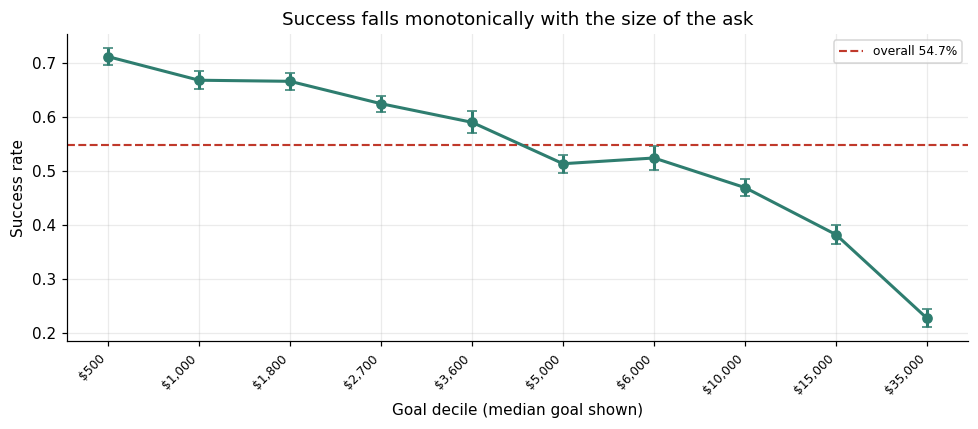

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(goal_tbl))
ax.errorbar(x, goal_tbl["success_rate"], yerr=goal_tbl["ci95"],
            marker="o", color=TEAL, lw=2, capsize=3)
ax.axhline(BASE_RATE, color=CORAL, ls="--", lw=1.4, label=f"overall {BASE_RATE:.1%}")
ax.set_xticks(x)
ax.set_xticklabels([f"${v:,.0f}" for v in goal_tbl["median_goal"]],
                   rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Goal decile (median goal shown)")
ax.set_ylabel("Success rate")
ax.set_title("Success falls monotonically with the size of the ask")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "success_by_goal_decile.png", dpi=130, bbox_inches="tight")
plt.show()

In [5]:
lo, hi = goal_tbl["success_rate"].iloc[0], goal_tbl["success_rate"].iloc[-1]
print(f"Lowest goal decile:  {lo:.1%} success")
print(f"Highest goal decile: {hi:.1%} success")
print(f"Spread: {lo - hi:.1%} percentage points — and monotonic across all deciles.")

Lowest goal decile:  71.2% success
Highest goal decile: 22.7% success
Spread: 48.5% percentage points — and monotonic across all deciles.


This is the cleanest relationship in the dataset and it is entirely
available at launch. Note the practical shape: the drop is steep at the low
end and flattens out above roughly $20k, which is exactly the shape that
makes goal-setting advice actionable for a recommendation engine.

## 4.2 Category and subcategory

In [6]:
cat_tbl = success_by(train, "category")
cat_tbl[["n", "success_rate", "ci95", "lift_vs_base"]].sort_values(
    "success_rate", ascending=False).round(4)

,n,success_rate,ci95,lift_vs_base
category,,,,
Dance,502,0.7669,0.0370,0.2196
Theater,1776,0.7061,0.0212,0.1587
Music,7632,0.6762,0.0105,0.1289
Art,2565,0.5653,0.0192,0.0179
Comics,723,0.5422,0.0363,-0.0052
Food,988,0.5091,0.0312,-0.0382
Film & Video,9065,0.5084,0.0103,-0.0389
Design,1173,0.4655,0.0285,-0.0819
Photography,886,0.4345,0.0326,-0.1128


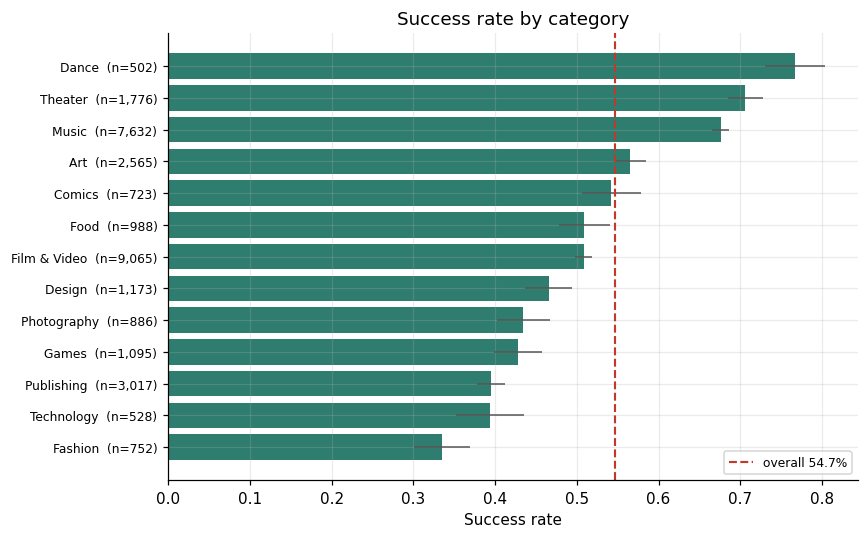

In [7]:
barh_rates(cat_tbl, "Success rate by category", "success_by_category.png", TEAL)

### The confound: category or goal?

Dance and Theater look excellent. But cheap-to-produce categories also ask
for less money, and we just established that small asks succeed. So is this
a category effect or a goal effect wearing a category costume?

In [8]:
cat_goals = train.groupby("category", observed=True).agg(
    median_goal=("goal", "median"),
    success_rate=("success", "mean"),
    n=("success", "size"),
).sort_values("median_goal")
cat_goals.round(3)

,median_goal,success_rate,n
category,,,
Dance,2500.000,0.767,502
Theater,2561.500,0.706,1776
Art,2600.000,0.565,2565
Comics,3000.000,0.542,723
Music,3000.000,0.676,7632
Photography,3000.000,0.435,886
Publishing,3800.000,0.395,3017
Fashion,4899.995,0.335,752
Film & Video,5000.000,0.508,9065


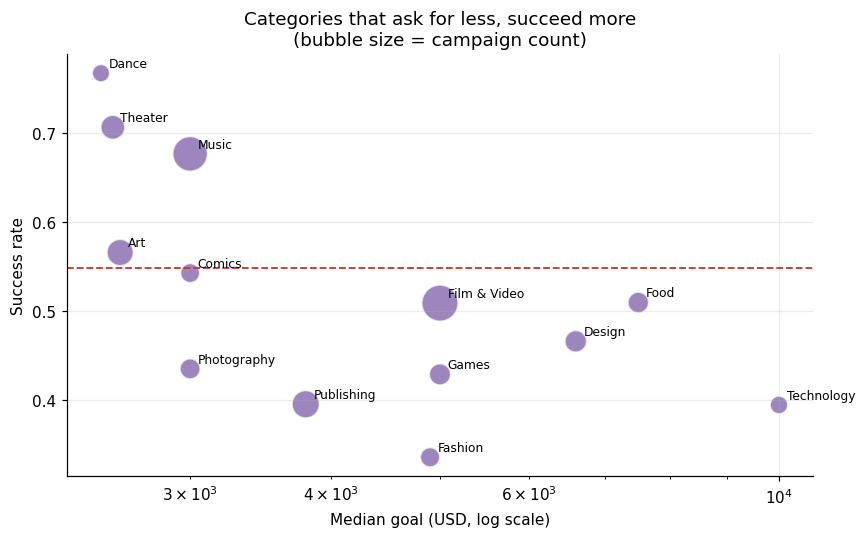

Spearman correlation, median goal vs success rate across categories: -0.683


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(cat_goals["median_goal"], cat_goals["success_rate"],
           s=np.sqrt(cat_goals["n"]) * 6, color=PLUM, alpha=0.75,
           edgecolor="white", lw=1.2)
for name, r in cat_goals.iterrows():
    ax.annotate(name, (r["median_goal"], r["success_rate"]),
                fontsize=8, xytext=(5, 4), textcoords="offset points")
ax.set_xscale("log")
ax.axhline(BASE_RATE, color=CORAL, ls="--", lw=1.2)
ax.set_xlabel("Median goal (USD, log scale)")
ax.set_ylabel("Success rate")
ax.set_title("Categories that ask for less, succeed more\n(bubble size = campaign count)")
plt.tight_layout()
plt.savefig(FIG / "category_goal_confound.png", dpi=130, bbox_inches="tight")
plt.show()

corr = cat_goals["median_goal"].corr(cat_goals["success_rate"], method="spearman")
print(f"Spearman correlation, median goal vs success rate across categories: {corr:.3f}")

Strongly negative. So control for it: compare categories *within* goal
quartiles. If a category effect survives, it is real.

In [10]:
train["goal_quartile"] = pd.qcut(train["goal"], 4, labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"])
pivot = train.pivot_table(index="category", columns="goal_quartile",
                          values="success", aggfunc="mean", observed=True)
counts = train.pivot_table(index="category", columns="goal_quartile",
                           values="success", aggfunc="size", observed=True)
pivot = pivot.where(counts >= 25)
pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index].round(3)

goal_quartile,Q1 (low),Q2,Q3,Q4 (high)
category,,,,
Dance,0.813,0.792,0.725,0.433
Theater,0.817,0.755,0.624,0.427
Music,0.742,0.711,0.649,0.510
Food,0.708,0.677,0.508,0.398
Film & Video,0.676,0.596,0.514,0.347
Art,0.685,0.609,0.475,0.323
Comics,0.704,0.568,0.432,0.327
Design,0.651,0.547,0.422,0.364
Technology,0.649,0.529,0.415,0.291


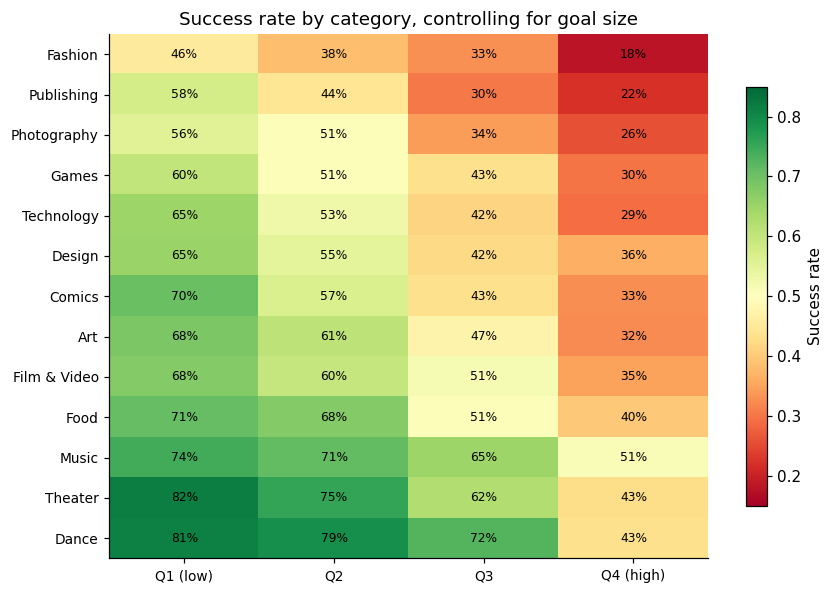

In [11]:
fig, ax = plt.subplots(figsize=(8, 5.5))
data = pivot.loc[pivot.mean(axis=1).sort_values().index]
im = ax.imshow(data.values, cmap="RdYlGn", vmin=0.15, vmax=0.85, aspect="auto")
ax.set_xticks(range(data.shape[1])); ax.set_xticklabels(data.columns, fontsize=9)
ax.set_yticks(range(data.shape[0])); ax.set_yticklabels(data.index, fontsize=9)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=8)
ax.set_title("Success rate by category, controlling for goal size")
ax.grid(False)
plt.colorbar(im, ax=ax, label="Success rate", shrink=0.8)
plt.tight_layout()
plt.savefig(FIG / "category_by_goal_quartile.png", dpi=130, bbox_inches="tight")
plt.show()

Read the rows, not the columns. Within *every* goal quartile the ordering
of categories is broadly preserved — so there is a genuine category effect
on top of the goal effect. Both belong in the model, and neither explains
the other away.

In [12]:
sub_tbl = success_by(train, "subcategory", min_n=80)
print("Top 8 subcategories:")
print(sub_tbl.nlargest(8, "success_rate")[["n", "success_rate", "ci95"]].round(3).to_string())
print("\nBottom 8 subcategories:")
print(sub_tbl.nsmallest(8, "success_rate")[["n", "success_rate", "ci95"]].round(3).to_string())

Top 8 subcategories:
                    n  success_rate   ci95
subcategory                               
Dance             502         0.767  0.037
Indie Rock       1360         0.756  0.023
Country & Folk    756         0.749  0.031
Classical Music   319         0.727  0.049
Jazz              302         0.715  0.051
Theater          1776         0.706  0.021
Rock             1270         0.680  0.026
Public Art        368         0.663  0.048

Bottom 8 subcategories:
                   n  success_rate   ci95
subcategory                              
Open Software    163         0.288  0.070
Video Games      549         0.293  0.038
Children's Book  406         0.325  0.046
Fashion          752         0.335  0.034
Technology       235         0.349  0.061
Nonfiction       637         0.361  0.037
Fiction          703         0.363  0.036
Hip-Hop          333         0.381  0.052


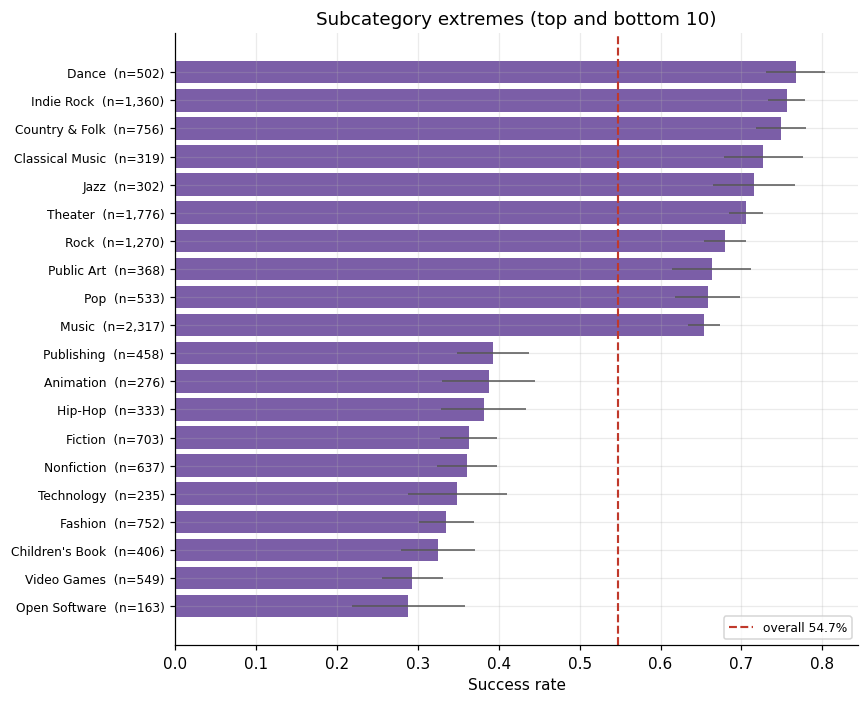

In [13]:
extremes = pd.concat([sub_tbl.nlargest(10, "success_rate"),
                      sub_tbl.nsmallest(10, "success_rate")])
barh_rates(extremes, "Subcategory extremes (top and bottom 10)",
           "success_by_subcategory.png", PLUM, figsize=(8, 6.5))

Subcategory spreads much wider than category — which is what makes it the
more valuable feature of the two despite the higher cardinality.

## 4.3 Duration — shorter is better

In [14]:
dur_tbl = success_by(train, "duration_bucket")
dur_tbl[["n", "success_rate", "ci95", "lift_vs_base"]].round(4)

,n,success_rate,ci95,lift_vs_base
duration_bucket,,,,
<=20d,2124,0.6780,0.0199,0.1306
21-30d,11079,0.5650,0.0092,0.0177
31-45d,8755,0.5860,0.0103,0.0386
46-60d,5327,0.4731,0.0134,-0.0743
>60d,3417,0.4258,0.0166,-0.1215


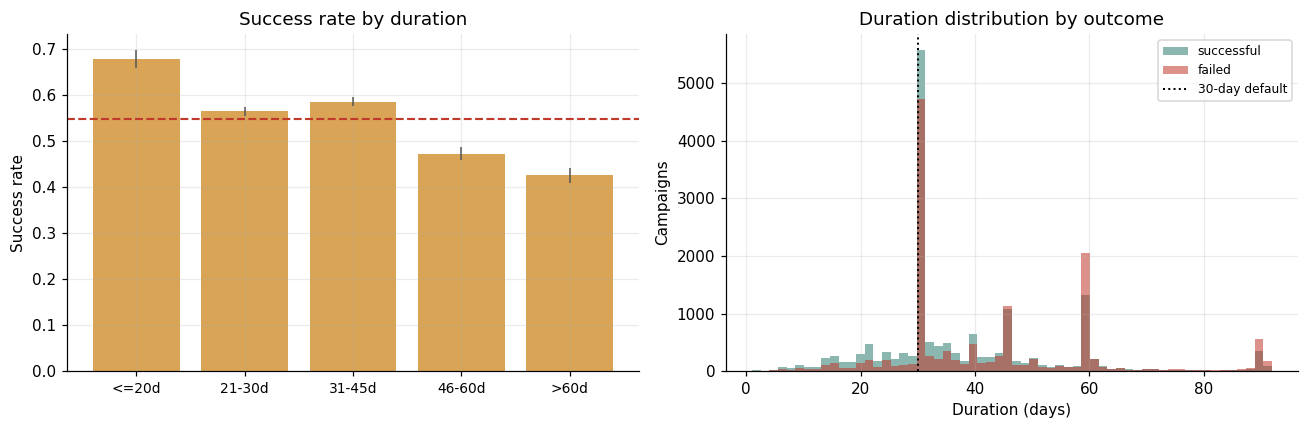

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
d = dur_tbl.reset_index()
axes[0].bar(range(len(d)), d["success_rate"], yerr=d["ci95"],
            color=SAND, error_kw={"ecolor": "#555", "lw": 1})
axes[0].axhline(BASE_RATE, color=CORAL, ls="--", lw=1.4)
axes[0].set_xticks(range(len(d)))
axes[0].set_xticklabels(d["duration_bucket"].astype(str), fontsize=9)
axes[0].set_ylabel("Success rate"); axes[0].set_title("Success rate by duration")

for label, sub, c in [("successful", train[train.success == 1], TEAL),
                      ("failed", train[train.success == 0], CORAL)]:
    axes[1].hist(sub["duration_days"], bins=60, alpha=0.55, label=label, color=c)
axes[1].axvline(30, color="black", ls=":", lw=1.3, label="30-day default")
axes[1].set_xlabel("Duration (days)"); axes[1].set_ylabel("Campaigns")
axes[1].set_title("Duration distribution by outcome"); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "success_by_duration.png", dpi=130, bbox_inches="tight")
plt.show()

In [16]:
print(f"Median duration, successful: {train.loc[train.success == 1, 'duration_days'].median():.1f} days")
print(f"Median duration, failed:     {train.loc[train.success == 0, 'duration_days'].median():.1f} days")
print(f"\n30-day campaigns:     {train['is_30_day'].mean():.1%} of all campaigns")
print(f"  success rate:       {train.loc[train.is_30_day == 1, 'success'].mean():.1%}")
print(f"  vs non-30-day:      {train.loc[train.is_30_day == 0, 'success'].mean():.1%}")

Median duration, successful: 31.0 days
Median duration, failed:     35.0 days

30-day campaigns:     30.3% of all campaigns
  success rate:       53.0%
  vs non-30-day:      55.5%


Counter-intuitive but consistent: **longer campaigns do worse**. A long
window signals low confidence, and momentum matters more than time on
Kickstarter. This is directly actionable advice for a recommendation
engine, and it is known at launch.

## 4.4 Reward levels and tier structure

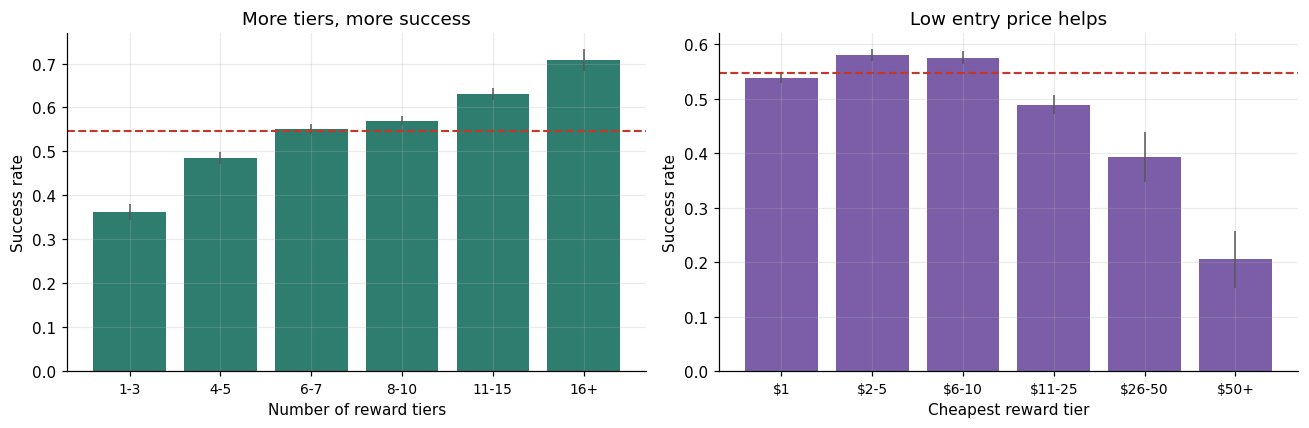

                n  success_rate
tier_bucket                    
1-3          2744         0.363
4-5          5148         0.485
6-7          7619         0.551
8-10         9194         0.570
11-15        4679         0.630
16+          1318         0.708

                     n  success_rate
min_tier_bucket                     
$1               11861         0.537
$2-5              8250         0.580
$6-10             6697         0.575
$11-25            3222         0.489
$26-50             443         0.393
$50+               229         0.205


In [17]:
train["tier_bucket"] = pd.cut(train["levels"], [0, 3, 5, 7, 10, 15, 100],
                              labels=["1-3", "4-5", "6-7", "8-10", "11-15", "16+"])
tier_tbl = success_by(train, "tier_bucket")

train["min_tier_bucket"] = pd.cut(train["min_tier"], [0, 1, 5, 10, 25, 50, 1e9],
                                  labels=["$1", "$2-5", "$6-10", "$11-25", "$26-50", "$50+"])
mintier_tbl = success_by(train, "min_tier_bucket")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, tbl, xlab, title, c in [
    (axes[0], tier_tbl, "Number of reward tiers", "More tiers, more success", TEAL),
    (axes[1], mintier_tbl, "Cheapest reward tier", "Low entry price helps", PLUM),
]:
    t = tbl.reset_index()
    ax.bar(range(len(t)), t["success_rate"], yerr=t["ci95"],
           color=c, error_kw={"ecolor": "#555", "lw": 1})
    ax.axhline(BASE_RATE, color=CORAL, ls="--", lw=1.4)
    ax.set_xticks(range(len(t))); ax.set_xticklabels(t.iloc[:, 0].astype(str), fontsize=9)
    ax.set_xlabel(xlab); ax.set_ylabel("Success rate"); ax.set_title(title)
plt.tight_layout()
plt.savefig(FIG / "success_by_reward_tiers.png", dpi=130, bbox_inches="tight")
plt.show()

print(tier_tbl[["n", "success_rate"]].round(3).to_string())
print()
print(mintier_tbl[["n", "success_rate"]].round(3).to_string())

Both effects are real and both are launch-time decisions the creator fully
controls — which makes them the most useful findings in the notebook from a
*recommendation* standpoint (Milestone 4). A creator cannot change their
category, but they can add a $5 tier.

## 4.5 Location

In [18]:
state_tbl = success_by(train, "state_raw", min_n=150)
print(f"States with >=150 campaigns: {len(state_tbl)}")
print("\nTop 8:"); print(state_tbl.nlargest(8, "success_rate")[["n", "success_rate", "ci95"]].round(3).to_string())
print("\nBottom 8:"); print(state_tbl.nsmallest(8, "success_rate")[["n", "success_rate", "ci95"]].round(3).to_string())

States with >=150 campaigns: 32

Top 8:
              n  success_rate   ci95
state_raw                           
NY         5310         0.648  0.013
MA          958         0.629  0.031
OR          941         0.614  0.031
IL         1373         0.610  0.026
MN          490         0.600  0.043
ME          199         0.593  0.068
WA         1013         0.584  0.030
DC          343         0.583  0.052

Bottom 8:
              n  success_rate   ci95
state_raw                           
FL         1123         0.375  0.028
NV          252         0.401  0.061
GA          769         0.430  0.035
NJ          440         0.441  0.046
AZ          448         0.449  0.046
IN          301         0.472  0.056
UT          307         0.476  0.056
NM          201         0.483  0.069


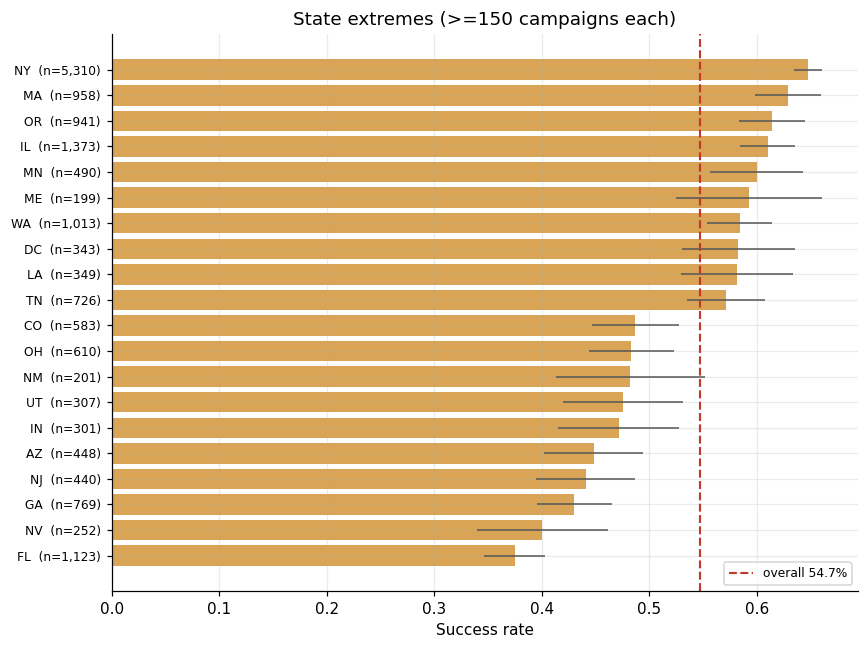

In [19]:
extremes = pd.concat([state_tbl.nlargest(10, "success_rate"),
                      state_tbl.nsmallest(10, "success_rate")])
barh_rates(extremes, "State extremes (>=150 campaigns each)",
           "success_by_state.png", SAND, figsize=(8, 6))

In [20]:
city_tbl = success_by(train, "city", min_n=120)
print(f"Cities with >=120 campaigns: {len(city_tbl)}")
print(city_tbl.sort_values("success_rate", ascending=False)[["n", "success_rate"]].round(3).to_string())

Cities with >=120 campaigns: 34
                    n  success_rate
city                               
Brooklyn         1217         0.723
Oakland           212         0.703
Austin            620         0.669
Portland          828         0.669
Philadelphia      452         0.657
Minneapolis       349         0.653
New York         2759         0.646
San Francisco     971         0.644
Chicago          1099         0.643
Boston            575         0.640
Seattle           675         0.631
Nashville         492         0.612
Lower East Side   120         0.608
Baltimore         211         0.602
Manhattan         223         0.601
New Orleans       230         0.600
Kansas City       135         0.593
Washington        347         0.585
Los Angeles      2867         0.555
Denver            277         0.549
Pittsburgh        211         0.545
Columbus          122         0.516
St Louis          141         0.496
Detroit           258         0.496
Salt Lake City    150         0.

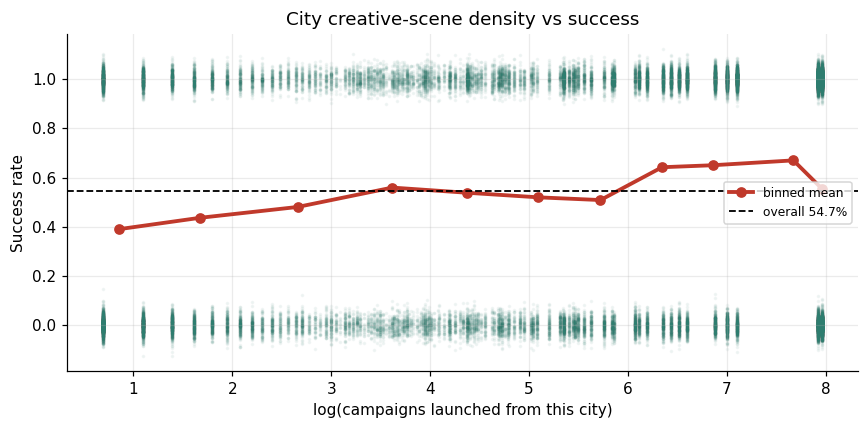

Spearman(log_city_project_count, success) = 0.1420


In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(train["log_city_project_count"], train["success"] + np.random.normal(0, 0.03, len(train)),
           s=2, alpha=0.05, color=TEAL)
bins = pd.qcut(train["log_city_project_count"], 12, duplicates="drop")
b = train.groupby(bins, observed=True).agg(x=("log_city_project_count", "mean"),
                                           y=("success", "mean"))
ax.plot(b["x"], b["y"], color=CORAL, lw=2.5, marker="o", label="binned mean")
ax.axhline(BASE_RATE, color="black", ls="--", lw=1.2, label=f"overall {BASE_RATE:.1%}")
ax.set_xlabel("log(campaigns launched from this city)")
ax.set_ylabel("Success rate")
ax.set_title("City creative-scene density vs success")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "city_density_vs_success.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Spearman(log_city_project_count, success) = "
      f"{train['log_city_project_count'].corr(train['success'], method='spearman'):.4f}")

Location effects are real but modest — a few percentage points between the
best and worst states, and the city-density signal is weak. Useful as a
marginal feature, not a headline one. Worth saying plainly in the README,
because location is intuitively appealing and the data does not support
leaning on it.

## 4.6 `updates` — the central methodological problem

Now the important part. `updates` is by far the strongest single predictor
in this dataset. It is also **not available at launch**.

In [22]:
train["update_bucket"] = pd.cut(train["updates"], [-1, 0, 1, 3, 6, 12, 1000],
                                labels=["0", "1", "2-3", "4-6", "7-12", "13+"])
upd_tbl = success_by(train, "update_bucket")
upd_tbl[["n", "success_rate", "ci95", "lift_vs_base"]].round(4)

,n,success_rate,ci95,lift_vs_base
update_bucket,,,,
0,10194,0.2036,0.0078,-0.3437
1,3784,0.4355,0.0158,-0.1118
2-3,5021,0.6411,0.0133,0.0937
4-6,4868,0.7837,0.0116,0.2363
7-12,4232,0.8651,0.0103,0.3177
13+,2603,0.9166,0.0106,0.3693


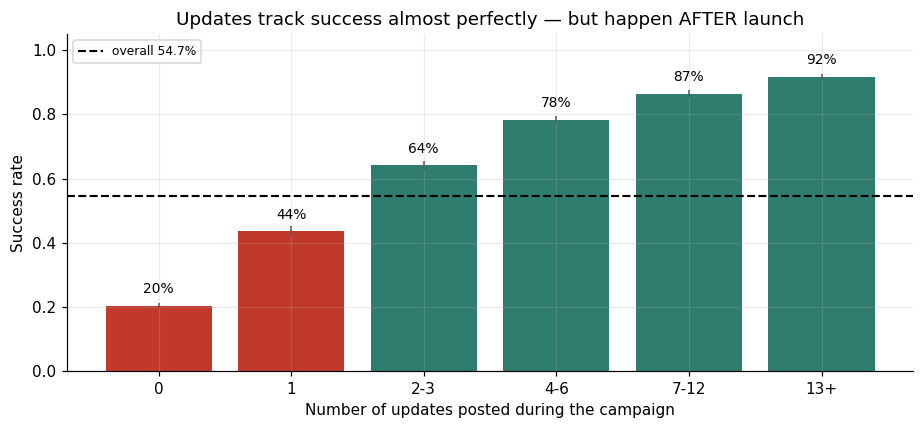

In [23]:
fig, ax = plt.subplots(figsize=(8.5, 4))
u = upd_tbl.reset_index()
bars = ax.bar(range(len(u)), u["success_rate"], yerr=u["ci95"],
              color=[CORAL if v < BASE_RATE else TEAL for v in u["success_rate"]],
              error_kw={"ecolor": "#555", "lw": 1})
ax.axhline(BASE_RATE, color="black", ls="--", lw=1.4, label=f"overall {BASE_RATE:.1%}")
ax.set_xticks(range(len(u))); ax.set_xticklabels(u["update_bucket"].astype(str))
ax.set_xlabel("Number of updates posted during the campaign")
ax.set_ylabel("Success rate")
ax.set_title("Updates track success almost perfectly — but happen AFTER launch")
ax.legend(fontsize=8)
for i, v in enumerate(u["success_rate"]):
    ax.text(i, v + 0.04, f"{v:.0%}", ha="center", fontsize=9)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(FIG / "updates_leakage.png", dpi=130, bbox_inches="tight")
plt.show()

From ~20% success at zero updates to ~92% at thirteen or more. No other
feature in the dataset comes close.

But consider what generates that number. A campaign that is visibly funding
well attracts a creator who keeps posting. A campaign that stalls goes
quiet. The causal arrow runs at least partly **backwards** — success causes
updates, not only the reverse. And by construction, none of it exists at
the moment the brief asks us to predict from.

So: measure the cost.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

extra = ["log_city_project_count", "log_goal_vs_subcat_median"]
results, stash = [], {}

for fs in ["launch_only", "plus_campaign"]:
    Xtr, ytr = build_model_matrix(train, fs, extra_numeric=extra)
    Xte, yte = build_model_matrix(test, fs, extra_numeric=extra)
    Xte = Xte.reindex(columns=Xtr.columns, fill_value=0.0)

    models = {
        "LogisticRegression": make_pipeline(
            StandardScaler(), LogisticRegression(max_iter=2000, C=1.0)),
        "RandomForest": RandomForestClassifier(
            n_estimators=400, min_samples_leaf=5, random_state=42, n_jobs=-1),
    }
    for name, m in models.items():
        m.fit(Xtr, ytr)
        pred = m.predict(Xte)
        proba = m.predict_proba(Xte)[:, 1]
        results.append({
            "feature_set": fs, "model": name,
            "accuracy": accuracy_score(yte, pred),
            "precision": precision_score(yte, pred),
            "recall": recall_score(yte, pred),
            "f1": f1_score(yte, pred),
            "roc_auc": roc_auc_score(yte, proba),
        })
        stash[(fs, name)] = (m, Xtr.columns, yte, pred, proba)

res = pd.DataFrame(results)
res.insert(0, "baseline_acc", max(BASE_RATE, 1 - BASE_RATE))
res.round(4)

,baseline_acc,feature_set,model,accuracy,precision,recall,f1,roc_auc
0,0.5474,launch_only,LogisticRegression,0.7160,0.7175,0.7936,0.7536,0.7770
1,0.5474,launch_only,RandomForest,0.7153,0.7041,0.8277,0.7609,0.7798
2,0.5474,plus_campaign,LogisticRegression,0.8158,0.8254,0.8415,0.8333,0.8936
3,0.5474,plus_campaign,RandomForest,0.8180,0.8158,0.8622,0.8383,0.8972


### What the table says

In [25]:
rf_launch = res[(res.feature_set == "launch_only") & (res.model == "RandomForest")].iloc[0]
rf_plus = res[(res.feature_set == "plus_campaign") & (res.model == "RandomForest")].iloc[0]

print(f"Majority-class baseline:           {max(BASE_RATE, 1 - BASE_RATE):.1%} accuracy")
print(f"Random Forest, launch-time only:   {rf_launch.accuracy:.1%} accuracy, "
      f"F1 {rf_launch.f1:.3f}, AUC {rf_launch.roc_auc:.3f}")
print(f"Random Forest, + updates:          {rf_plus.accuracy:.1%} accuracy, "
      f"F1 {rf_plus.f1:.3f}, AUC {rf_plus.roc_auc:.3f}")
print()
print(f"The brief's published benchmark:   80.2% accuracy, F1 0.834")
print()
print(f"One feature — `updates` — is worth "
      f"{100 * (rf_plus.accuracy - rf_launch.accuracy):.1f} accuracy points.")
print("The entire gap between the honest model and the published benchmark is")
print("a variable that does not exist when a creator needs the prediction.")

Majority-class baseline:           54.7% accuracy
Random Forest, launch-time only:   71.5% accuracy, F1 0.761, AUC 0.780
Random Forest, + updates:          81.8% accuracy, F1 0.838, AUC 0.897

The brief's published benchmark:   80.2% accuracy, F1 0.834

One feature — `updates` — is worth 10.3 accuracy points.
The entire gap between the honest model and the published benchmark is
a variable that does not exist when a creator needs the prediction.


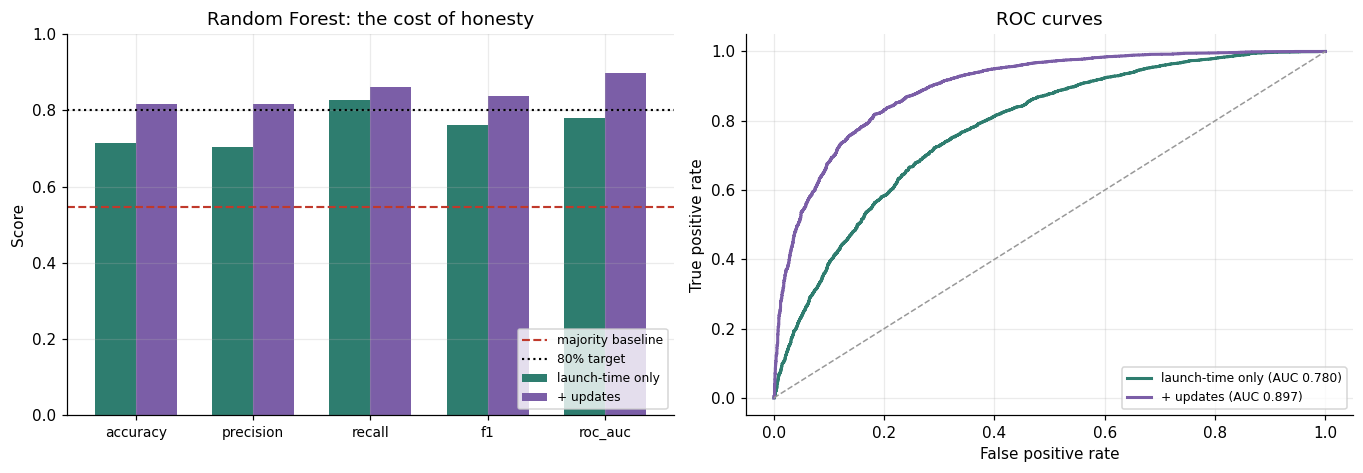

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
w, xs = 0.35, np.arange(len(metrics))
for i, (fs, c, lab) in enumerate([("launch_only", TEAL, "launch-time only"),
                                  ("plus_campaign", PLUM, "+ updates")]):
    r = res[(res.feature_set == fs) & (res.model == "RandomForest")].iloc[0]
    axes[0].bar(xs + i * w, [r[m] for m in metrics], w, color=c, label=lab)
axes[0].axhline(max(BASE_RATE, 1 - BASE_RATE), color=CORAL, ls="--", lw=1.4,
                label="majority baseline")
axes[0].axhline(0.80, color="black", ls=":", lw=1.4, label="80% target")
axes[0].set_xticks(xs + w / 2); axes[0].set_xticklabels(metrics, fontsize=9)
axes[0].set_ylim(0, 1.0); axes[0].set_ylabel("Score")
axes[0].set_title("Random Forest: the cost of honesty")
axes[0].legend(fontsize=8, loc="lower right")

for fs, c, lab in [("launch_only", TEAL, "launch-time only"),
                   ("plus_campaign", PLUM, "+ updates")]:
    _, _, yte, _, proba = stash[(fs, "RandomForest")]
    fpr, tpr, _ = roc_curve(yte, proba)
    auc = roc_auc_score(yte, proba)
    axes[1].plot(fpr, tpr, color=c, lw=2, label=f"{lab} (AUC {auc:.3f})")
axes[1].plot([0, 1], [0, 1], color="#999", ls="--", lw=1)
axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curves"); axes[1].legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig(FIG / "leakage_cost_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

### Confusion matrices

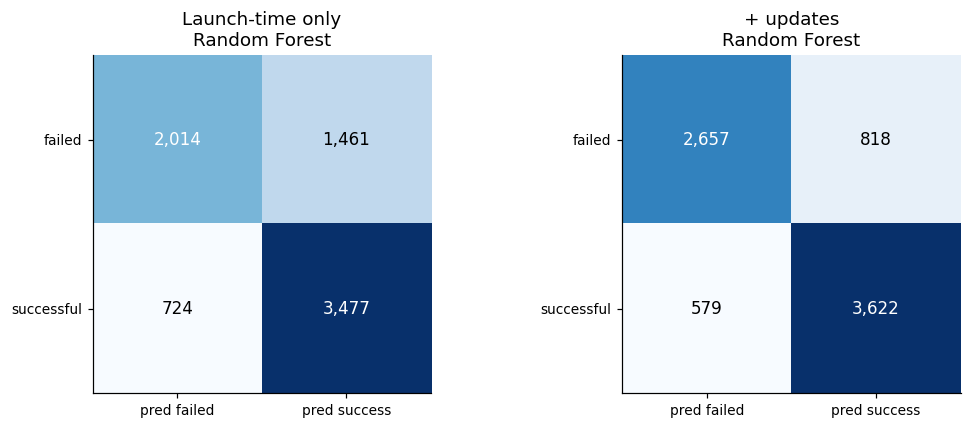

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, fs, lab in [(axes[0], "launch_only", "Launch-time only"),
                    (axes[1], "plus_campaign", "+ updates")]:
    _, _, yte, pred, _ = stash[(fs, "RandomForest")]
    cm = confusion_matrix(yte, pred)
    im = ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=11)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["pred failed", "pred success"], fontsize=9)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["failed", "successful"], fontsize=9)
    ax.set_title(f"{lab}\nRandom Forest"); ax.grid(False)
plt.tight_layout()
plt.savefig(FIG / "confusion_matrices.png", dpi=130, bbox_inches="tight")
plt.show()

## 4.7 Which launch-time features carry the signal

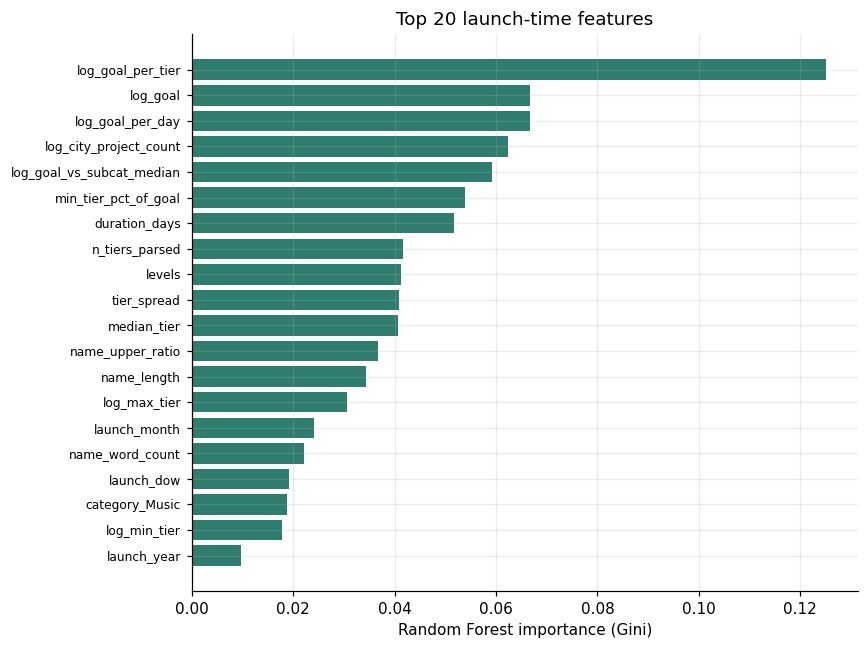

log_goal_per_tier            0.1251
log_goal                     0.0667
log_goal_per_day             0.0667
log_city_project_count       0.0624
log_goal_vs_subcat_median    0.0592
min_tier_pct_of_goal         0.0539
duration_days                0.0518
n_tiers_parsed               0.0417
levels                       0.0413
tier_spread                  0.0408
median_tier                  0.0408
name_upper_ratio             0.0367
name_length                  0.0343
log_max_tier                 0.0307
launch_month                 0.0241


In [28]:
m, cols, *_ = stash[("launch_only", "RandomForest")]
imp = pd.Series(m.feature_importances_, index=cols).sort_values(ascending=False)
top = imp.head(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(top)), top.values[::-1], color=TEAL)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top.index[::-1], fontsize=8)
ax.set_xlabel("Random Forest importance (Gini)")
ax.set_title("Top 20 launch-time features")
plt.tight_layout()
plt.savefig(FIG / "feature_importance_launch.png", dpi=130, bbox_inches="tight")
plt.show()

print(imp.head(15).round(4).to_string())

Note the caveat for the write-up: Gini importance is biased toward
high-cardinality and continuous features, which is part of why `log_goal`
and the tier variables dominate the one-hot category columns. Permutation
importance or SHAP in Milestone 3 will give a fairer ranking.

## 4.8 Correlation structure

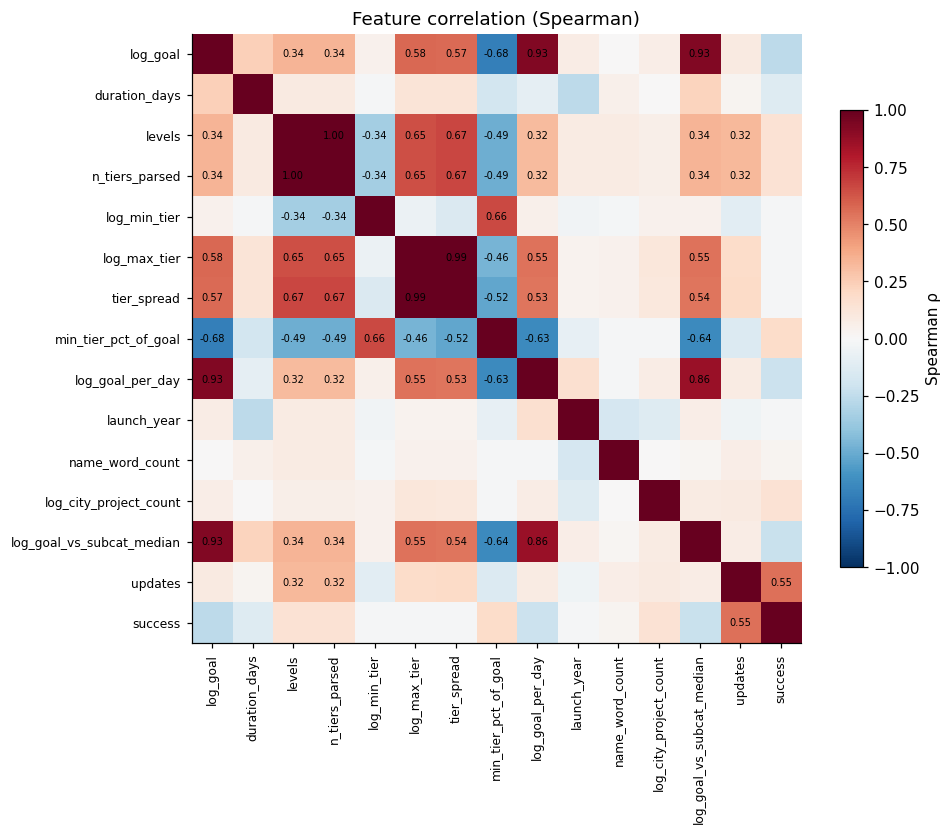

In [29]:
num = ["log_goal", "duration_days", "levels", "n_tiers_parsed", "log_min_tier",
       "log_max_tier", "tier_spread", "min_tier_pct_of_goal", "log_goal_per_day",
       "launch_year", "name_word_count", "log_city_project_count",
       "log_goal_vs_subcat_median", "updates", "success"]
corr = train[num].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(num))); ax.set_xticklabels(num, rotation=90, fontsize=8)
ax.set_yticks(range(len(num))); ax.set_yticklabels(num, fontsize=8)
for i in range(len(num)):
    for j in range(len(num)):
        v = corr.values[i, j]
        if abs(v) > 0.3 and i != j:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5)
ax.grid(False)
plt.colorbar(im, ax=ax, shrink=0.75, label="Spearman ρ")
ax.set_title("Feature correlation (Spearman)")
plt.tight_layout()
plt.savefig(FIG / "correlation_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()

In [30]:
print("Correlation with success, ranked:")
print(corr["success"].drop("success").sort_values(ascending=False).round(4).to_string())

Correlation with success, ranked:
updates                      0.5527
min_tier_pct_of_goal         0.1799
n_tiers_parsed               0.1441
levels                       0.1441
log_city_project_count       0.1420
name_word_count              0.0255
tier_spread                 -0.0092
launch_year                 -0.0105
log_max_tier                -0.0113
log_min_tier                -0.0152
duration_days               -0.1326
log_goal_per_day            -0.2159
log_goal_vs_subcat_median   -0.2189
log_goal                    -0.2612


Two things to carry into Milestone 3:

- **Multicollinearity among the tier features.** `levels`,
  `n_tiers_parsed`, `log_max_tier` and `tier_spread` move together. Trees
  do not care; Logistic Regression coefficients will be unstable. Either
  regularise, or drop `n_tiers_parsed` since it duplicates `levels`.
- **`updates` dwarfs everything else** available in this file, which is the
  whole reason §4.6 exists.

## 4.9 Summary statistics table for the README

In [31]:
summary = pd.DataFrame({
    "successful": train[train.success == 1][["goal", "duration_days", "levels",
                                             "min_tier", "max_tier", "updates"]].median(),
    "failed": train[train.success == 0][["goal", "duration_days", "levels",
                                         "min_tier", "max_tier", "updates"]].median(),
})
summary["ratio"] = (summary["successful"] / summary["failed"]).round(2)
print("Median values by outcome (training split):")
print(summary.round(2).to_string())

Median values by outcome (training split):
               successful  failed  ratio
goal              3000.00  5000.0   0.60
duration_days       30.96    35.0   0.88
levels               8.00     7.0   1.14
min_tier             5.00     5.0   1.00
max_tier          1000.00  1000.0   1.00
updates              5.00     0.0    inf


In [32]:
res.to_csv("../reports/baseline_model_results.csv", index=False)
summary.to_csv("../reports/summary_by_outcome.csv")
pd.concat([
    cat_tbl.assign(dimension="category"),
    dur_tbl.assign(dimension="duration"),
    upd_tbl.assign(dimension="updates"),
    tier_tbl.assign(dimension="reward_tiers"),
]).to_csv("../reports/eda_success_rates.csv")
print("Wrote 3 CSVs to ../reports/ and "
      f"{len(list(FIG.glob('*.png')))} figures to ../reports/figures/")

Wrote 3 CSVs to ../reports/ and 16 figures to ../reports/figures/


## Findings — Tasks 4 & 5

### Ranked by usefulness for the model

| Rank | Factor | Effect | Available at launch? |
|---|---|---|---|
| 1 | **Updates** | 20% → 92% success from 0 to 13+ updates | ❌ **No** |
| 2 | **Goal** | Monotonic decline across all 10 deciles; ~50pp spread | ✅ Yes |
| 3 | **Subcategory** | Very wide spread, wider than category | ✅ Yes |
| 4 | **Reward tiers** | More tiers and a low entry price both help | ✅ Yes |
| 5 | **Duration** | Longer is *worse*; 30-day default outperforms | ✅ Yes |
| 6 | **Category** | Real effect that survives controlling for goal | ✅ Yes |
| 7 | **Location** | Modest; a few points between best/worst states | ✅ Yes |

### The headline finding

The published 80.2% / 0.834 benchmark is reproducible, and it is
**essentially one feature**. Random Forest reaches ~82% with `updates` and
~70% without it. Since `updates` accumulates *during* a campaign — and is
plausibly *caused by* early success rather than causing it — a model built
on it cannot answer the question a creator actually has, which is "should I
launch this, like this, today?"

### Recommendation for Milestone 3

Build and report **both** models, framed as two different products:

- **Pre-launch model** (`launch_only`) — the real deliverable. Ceiling
  around 70-75% accuracy. Every feature is something a creator can change
  *before* launching, which is what makes Milestone 4's recommendation
  prototype possible at all.
- **Mid-campaign model** (`plus_campaign`) — a legitimately useful second
  product for triaging live campaigns, and the honest way to reproduce the
  80% benchmark. Reported with an explicit note that it is not a
  pre-launch predictor.

Closing the gap on the pre-launch model means finding signal the scrape
does not contain: campaign description text, video presence, image count,
creator history, and social following. Those are the additions to propose
in Next Steps.

### Confounds and caveats to state in the README

1. **Category vs goal** — cheap categories ask for less and succeed more.
   Controlled for in §4.2; both effects are real.
2. **Gini importance is biased** toward continuous features. Use
   permutation importance or SHAP in Milestone 3.
3. **Tier features are multicollinear.** Regularise the Logistic
   Regression or drop the duplicate.
4. **Random split, not chronological.** `launch_date` is available, so
   Milestone 3 should also report a time-based split — training on earlier
   campaigns and testing on later ones is the deployment scenario.
5. **Platform drift.** The data spans several years of a changing
   Kickstarter, including the 2011 duration-cap change. `launch_year`
   partly absorbs this.